# 환경 설정

In [15]:
from pathlib import Path
import sys

repo_dir = Path(".").resolve()
src_dir = repo_dir / "src"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print("repo_dir:", repo_dir)
print("src_dir:", src_dir)
print("src exists:", src_dir.exists())

repo_dir: C:\Jungle\Jungle_GPT_lab
src_dir: C:\Jungle\Jungle_GPT_lab\src
src exists: True


In [16]:
from finetune import (
    ReviewSentimentDataset,
    GPTForSequenceClassification,
    evaluate_sentiment,
)
from model import GPTModel
from bpe import BPETokenizer
import finetune
import model
import bpe
import train
from pathlib import Path
import sys
import json
import random
import importlib

import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

repo_dir = Path(".").resolve()
sys.path.insert(0, str(repo_dir / "src"))


importlib.reload(bpe)
importlib.reload(model)
importlib.reload(finetune)
importlib.reload(train)


print("repo_dir:", repo_dir)

repo_dir: C:\Jungle\Jungle_GPT_lab


# GPU 확인/ seed 고정

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device:", device)
if device.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

device: cuda
gpu: NVIDIA GeForce RTX 4070 Laptop GPU


# Fine-tuning 설정

In [18]:
FINETUNE_CFG = {
    "run_name": "sentiment_finetune",

    # tokenizer / model
    "tokenizer_vocab_size": 3000,
    "context_length": 128,
    "emb_dim": 256,
    "n_heads": 4,
    "n_layers": 4,
    "drop_rate": 0.2,
    "qkv_bias": False,

    # fine-tuning
    "num_epochs": 10,
    "batch_size": 128,
    "learning_rate": 2e-5,
    "weight_decay": 0.02,
    "classifier_drop_rate": 0.2,

    # loader
    "num_workers": 0,
    "seed": SEED,
}

FINETUNE_CFG

{'run_name': 'sentiment_finetune',
 'tokenizer_vocab_size': 3000,
 'context_length': 128,
 'emb_dim': 256,
 'n_heads': 4,
 'n_layers': 4,
 'drop_rate': 0.2,
 'qkv_bias': False,
 'num_epochs': 10,
 'batch_size': 128,
 'learning_rate': 2e-05,
 'weight_decay': 0.02,
 'classifier_drop_rate': 0.2,
 'num_workers': 0,
 'seed': 42}

# 경로 설정

In [19]:
tokenizer_path = repo_dir / "data" / \
    f"nsmc_bpe_vocab_{FINETUNE_CFG['tokenizer_vocab_size']}.json"

train_jsonl = repo_dir / "data" / "nsmc_sentiment_train.jsonl"
val_jsonl = repo_dir / "data" / "nsmc_sentiment_val.jsonl"
test_jsonl = repo_dir / "data" / "nsmc_sentiment_test.jsonl"

# 원하는 pretrain checkpoint로 바꿔도 됨
pretrain_checkpoint_path = repo_dir / "checkpoints" / "quick_pretrain_final.pt"

checkpoint_dir = repo_dir / "checkpoints"
best_finetune_path = checkpoint_dir / f"{FINETUNE_CFG['run_name']}_best.pt"
final_finetune_path = checkpoint_dir / f"{FINETUNE_CFG['run_name']}_final.pt"

for path in [tokenizer_path, train_jsonl, val_jsonl, test_jsonl]:
    print(path, "exists:", path.exists())

print("pretrain checkpoint:", pretrain_checkpoint_path,
      pretrain_checkpoint_path.exists())

C:\Jungle\Jungle_GPT_lab\data\nsmc_bpe_vocab_3000.json exists: True
C:\Jungle\Jungle_GPT_lab\data\nsmc_sentiment_train.jsonl exists: True
C:\Jungle\Jungle_GPT_lab\data\nsmc_sentiment_val.jsonl exists: True
C:\Jungle\Jungle_GPT_lab\data\nsmc_sentiment_test.jsonl exists: True
pretrain checkpoint: C:\Jungle\Jungle_GPT_lab\checkpoints\quick_pretrain_final.pt True


# Tokenizer 로드

In [20]:
tokenizer = BPETokenizer(vocab_size=FINETUNE_CFG["tokenizer_vocab_size"])
tokenizer.load(tokenizer_path)

vocab_size = max(tokenizer.id_to_token.keys()) + 1

print("loaded tokenizer:", tokenizer_path)
print("vocab_size:", vocab_size)
print("pad_id:", tokenizer.get_pad_id())

loaded tokenizer: C:\Jungle\Jungle_GPT_lab\data\nsmc_bpe_vocab_3000.json
vocab_size: 3000
pad_id: 0


# 감성 분류 데이터 로드

In [21]:
def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


train_data = load_jsonl(train_jsonl)
val_data = load_jsonl(val_jsonl)
test_data = load_jsonl(test_jsonl)

print(f"train: {len(train_data):,}")
print(f"val:   {len(val_data):,}")
print(f"test:  {len(test_data):,}")

print(train_data[0])

train: 137,996
val:   11,999
test:  49,997
{'text': '최고의영화네요 자야되는데 너무재미있어서 끝까지보고 이제잡니다 ㅋ', 'label': 1}


# 캐시용 import

In [22]:
import hashlib
import json
import time
from pathlib import Path

import torch
from torch.utils.data import TensorDataset, DataLoader

# 캐시 encode 함수

In [23]:
encoded_cache_dir = repo_dir / "checkpoints" / "finetune_encoded_cache"
encoded_cache_dir.mkdir(parents=True, exist_ok=True)


def make_cache_key(split_name, jsonl_path, tokenizer_path, cfg):
    payload = {
        "split": split_name,
        "jsonl_path": str(Path(jsonl_path).resolve()),
        "jsonl_mtime_ns": Path(jsonl_path).stat().st_mtime_ns,
        "tokenizer_path": str(Path(tokenizer_path).resolve()),
        "tokenizer_mtime_ns": Path(tokenizer_path).stat().st_mtime_ns,
        "tokenizer_vocab_size": cfg["tokenizer_vocab_size"],
        "context_length": cfg["context_length"],
        "encoding": "sentiment_no_bos_eos_pad_truncate",
    }
    text = json.dumps(payload, sort_keys=True, ensure_ascii=False)
    return hashlib.sha256(text.encode("utf-8")).hexdigest()[:12]


def encode_sentiment_data(data, tokenizer, max_length, name):
    pad_id = tokenizer.get_pad_id()

    input_ids = torch.empty((len(data), max_length), dtype=torch.long)
    labels = torch.empty((len(data),), dtype=torch.long)

    start = time.perf_counter()

    for idx, item in enumerate(data):
        ids = tokenizer.encode(item["text"])

        if len(ids) > max_length:
            ids = ids[:max_length]
        else:
            ids = ids + [pad_id] * (max_length - len(ids))

        input_ids[idx] = torch.tensor(ids, dtype=torch.long)
        labels[idx] = int(item["label"])

        if (idx + 1) % 5000 == 0 or idx + 1 == len(data):
            elapsed = time.perf_counter() - start
            print(
                f"[encode:{name}] {idx + 1:,}/{len(data):,} rows | {elapsed:.1f}s")

    return input_ids, labels


def load_or_build_encoded_cache(split_name, data, jsonl_path):
    cache_key = make_cache_key(
        split_name, jsonl_path, tokenizer_path, FINETUNE_CFG)
    cache_path = encoded_cache_dir / f"{split_name}_{cache_key}.pt"

    if cache_path.exists():
        print(f"[cache:{split_name}] loading {cache_path}")
        obj = torch.load(cache_path, map_location="cpu")
        return obj["input_ids"], obj["labels"], cache_path

    print(f"[cache:{split_name}] cache miss, encoding...")
    input_ids, labels = encode_sentiment_data(
        data,
        tokenizer,
        FINETUNE_CFG["context_length"],
        split_name,
    )

    torch.save(
        {
            "input_ids": input_ids,
            "labels": labels,
            "config": FINETUNE_CFG,
            "cache_key": cache_key,
        },
        cache_path,
    )

    print(f"[cache:{split_name}] saved {cache_path}")
    return input_ids, labels, cache_path

# train/val/test 인코딩 캐시 만들기

In [24]:
train_input_ids, train_labels, train_cache_path = load_or_build_encoded_cache(
    "train",
    train_data,
    train_jsonl,
)

val_input_ids, val_labels, val_cache_path = load_or_build_encoded_cache(
    "val",
    val_data,
    val_jsonl,
)

test_input_ids, test_labels, test_cache_path = load_or_build_encoded_cache(
    "test",
    test_data,
    test_jsonl,
)

print("train:", train_input_ids.shape, train_labels.shape)
print("val:", val_input_ids.shape, val_labels.shape)
print("test:", test_input_ids.shape, test_labels.shape)

[cache:train] loading C:\Jungle\Jungle_GPT_lab\checkpoints\finetune_encoded_cache\train_79fae2f0dddf.pt
[cache:val] loading C:\Jungle\Jungle_GPT_lab\checkpoints\finetune_encoded_cache\val_db3ef0dc8f25.pt
[cache:test] loading C:\Jungle\Jungle_GPT_lab\checkpoints\finetune_encoded_cache\test_56cdb70adc5d.pt
train: torch.Size([137996, 128]) torch.Size([137996])
val: torch.Size([11999, 128]) torch.Size([11999])
test: torch.Size([49997, 128]) torch.Size([49997])


# 기존 DataLoader를 캐시 기반으로 교체

In [25]:
train_ds = TensorDataset(train_input_ids, train_labels)
val_ds = TensorDataset(val_input_ids, val_labels)
test_ds = TensorDataset(test_input_ids, test_labels)

pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_ds,
    batch_size=FINETUNE_CFG["batch_size"],
    shuffle=True,
    num_workers=0,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_ds,
    batch_size=FINETUNE_CFG["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_ds,
    batch_size=FINETUNE_CFG["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

batch_input_ids, batch_labels = next(iter(train_loader))
print(batch_input_ids.shape, batch_labels.shape)

torch.Size([128, 128]) torch.Size([128])


# GPT backbone 설정 + pretrain checkpoint 로드

In [26]:
gpt_config = {
    "vocab_size": vocab_size,
    "context_length": FINETUNE_CFG["context_length"],
    "emb_dim": FINETUNE_CFG["emb_dim"],
    "n_heads": FINETUNE_CFG["n_heads"],
    "n_layers": FINETUNE_CFG["n_layers"],
    "drop_rate": FINETUNE_CFG["drop_rate"],
    "qkv_bias": FINETUNE_CFG["qkv_bias"],
}

backbone = GPTModel(gpt_config)

if pretrain_checkpoint_path.exists():
    checkpoint = torch.load(pretrain_checkpoint_path, map_location="cpu")
    state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
    backbone.load_state_dict(state_dict)
    print("loaded pretrained checkpoint:", pretrain_checkpoint_path)
else:
    print("pretrain checkpoint not found. training classifier from randomly initialized GPT backbone.")

gpt_config

loaded pretrained checkpoint: C:\Jungle\Jungle_GPT_lab\checkpoints\quick_pretrain_final.pt


{'vocab_size': 3000,
 'context_length': 128,
 'emb_dim': 256,
 'n_heads': 4,
 'n_layers': 4,
 'drop_rate': 0.2,
 'qkv_bias': False}

# 분류 모델 생성

In [27]:
clf_model = GPTForSequenceClassification(
    backbone,
    num_labels=2,
    drop_rate=FINETUNE_CFG["classifier_drop_rate"],
).to(device)

optimizer = torch.optim.AdamW(
    clf_model.parameters(),
    lr=FINETUNE_CFG["learning_rate"],
    weight_decay=FINETUNE_CFG["weight_decay"],
)

print(clf_model.__class__.__name__)
print("trainable parameters:",
      f"{sum(p.numel() for p in clf_model.parameters() if p.requires_grad):,}")

GPTForSequenceClassification
trainable parameters: 4,725,762


# 학습 루프

In [28]:
history = {
    "step": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_ppl": [],
    "generated_sample": [],
}

best_val_loss = float("inf")
best_epoch = 0
sample_prompt = "\uc774 \uc601\ud654\ub294"
sample_max_new_tokens = 30
sample_temperature = 0.8
sample_top_k = 40

checkpoint_dir.mkdir(parents=True, exist_ok=True)

print("| epoch | step | train_loss | val_loss | train_acc | val_acc | val_ppl |")
print("| --- | --- | --- | --- | --- | --- | --- |")
print("| epoch | \uc0dd\uc131 \uc0d8\ud50c |")
print("| --- | --- |")

for epoch in range(1, FINETUNE_CFG["num_epochs"] + 1):
    clf_model.train()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for batch_idx, (input_ids, labels) in enumerate(train_loader, start=1):
        input_ids = input_ids.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        loss, logits = clf_model(input_ids, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(clf_model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size = labels.size(0)
        preds = torch.argmax(logits, dim=-1)

        total_loss += loss.item() * batch_size
        total_correct += (preds == labels).sum().item()
        total_count += batch_size

        if batch_idx % 100 == 0:
            print(
                f"epoch {epoch} | [train] | "
                f"batch {batch_idx}/{len(train_loader)} | "
                f"loss {total_loss / total_count:.4f} | "
                f"acc {total_correct / total_count:.4f}"
            )

    train_loss = total_loss / total_count
    train_acc = total_correct / total_count

    val_loss, val_acc = evaluate_sentiment(clf_model, val_loader, device)
    step = epoch * len(train_loader)
    val_ppl = float(torch.exp(torch.tensor(val_loss)).item())

    history["step"].append(step)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_ppl"].append(val_ppl)

    print(
        f"| {epoch} | {step} | {train_loss:.4f} | {val_loss:.4f} | "
        f"{train_acc:.4f} | {val_acc:.4f} | {val_ppl:.4f} |"
    )

    was_training = clf_model.training
    clf_model.eval()
    with torch.no_grad():
        prompt_ids = train.text_to_token_ids(sample_prompt, tokenizer).to(device)
        sample_token_ids = train.generate(
            clf_model.gpt,
            prompt_ids,
            max_new_tokens=sample_max_new_tokens,
            context_size=gpt_config["context_length"],
            temperature=sample_temperature,
            top_k=sample_top_k,
        )
    if was_training:
        clf_model.train()

    sample_text = train.token_ids_to_text(sample_token_ids, tokenizer)
    sample_text = sample_text.replace("\n", " ").replace("|", "\\|").strip()
    history["generated_sample"].append(sample_text)
    print(f"| {epoch} | {sample_text} |")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch

        torch.save(
            {
                "model_state_dict": clf_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "config": FINETUNE_CFG,
                "gpt_config": gpt_config,
                "history": history,
                "best_val_loss": best_val_loss,
            },
            best_finetune_path,
        )

        print("saved best checkpoint:", best_finetune_path)

epoch 1 | [train] | batch 100/1079 | loss 0.7741 | acc 0.5310
epoch 1 | [train] | batch 200/1079 | loss 0.7482 | acc 0.5480
epoch 1 | [train] | batch 300/1079 | loss 0.7300 | acc 0.5642
epoch 1 | [train] | batch 400/1079 | loss 0.7153 | acc 0.5762
epoch 1 | [train] | batch 500/1079 | loss 0.7046 | acc 0.5853
epoch 1 | [train] | batch 600/1079 | loss 0.6947 | acc 0.5948
epoch 1 | [train] | batch 700/1079 | loss 0.6842 | acc 0.6042
epoch 1 | [train] | batch 800/1079 | loss 0.6748 | acc 0.6128
epoch 1 | [train] | batch 900/1079 | loss 0.6666 | acc 0.6204
epoch 1 | [train] | batch 1000/1079 | loss 0.6608 | acc 0.6258
Epoch 01 summary
  [train] loss 0.6554 | acc 0.6303
  [val]   loss 0.5331 | acc 0.7281
saved best checkpoint: C:\Jungle\Jungle_GPT_lab\checkpoints\sentiment_finetune_best.pt
epoch 2 | [train] | batch 100/1079 | loss 0.5815 | acc 0.6987
epoch 2 | [train] | batch 200/1079 | loss 0.5756 | acc 0.7005
epoch 2 | [train] | batch 300/1079 | loss 0.5718 | acc 0.7039
epoch 2 | [train] |

# 최종 checkpoint 저장 + test 평가

In [29]:
torch.save(
    {
        "model_state_dict": clf_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": FINETUNE_CFG["num_epochs"],
        "config": FINETUNE_CFG,
        "gpt_config": gpt_config,
        "history": history,
    },
    final_finetune_path,
)

test_loss, test_acc = evaluate_sentiment(clf_model, test_loader, device)

final_train_loss = history["train_loss"][-1]
final_train_acc = history["train_acc"][-1]
final_val_loss = history["val_loss"][-1]
final_val_acc = history["val_acc"][-1]

print("| \ud56d\ubaa9 | \ub0b4\uc6a9 |")
print("| --- | --- |")
print(f"| final train loss | {final_train_loss:.4f} |")
print(f"| final validation loss | {final_val_loss:.4f} |")
print(f"| best validation loss | {best_val_loss:.4f} |")
print(f"| best epoch | {best_epoch} |")

print("final train acc:", f"{final_train_acc:.4f}")
print("final validation acc:", f"{final_val_acc:.4f}")
print("checkpoint path:", final_finetune_path)
print("test loss:", f"{test_loss:.4f}")
print("test acc:", f"{test_acc:.4f}")
print("best checkpoint:", best_finetune_path)

final train loss: 0.3972
final validation loss: 0.4210
best validation loss: 0.4210
best epoch: 10
checkpoint path: C:\Jungle\Jungle_GPT_lab\checkpoints\sentiment_finetune_final.pt
test loss: 0.4160
test acc: 0.8227
best checkpoint: C:\Jungle\Jungle_GPT_lab\checkpoints\sentiment_finetune_best.pt


# Loss 그래프

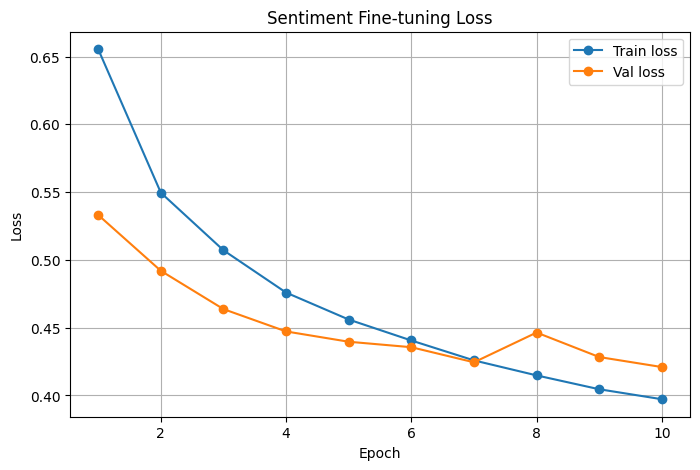

In [30]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sentiment Fine-tuning Loss")
plt.grid(True)
plt.legend()
plt.show()

# Accuracy 그래프

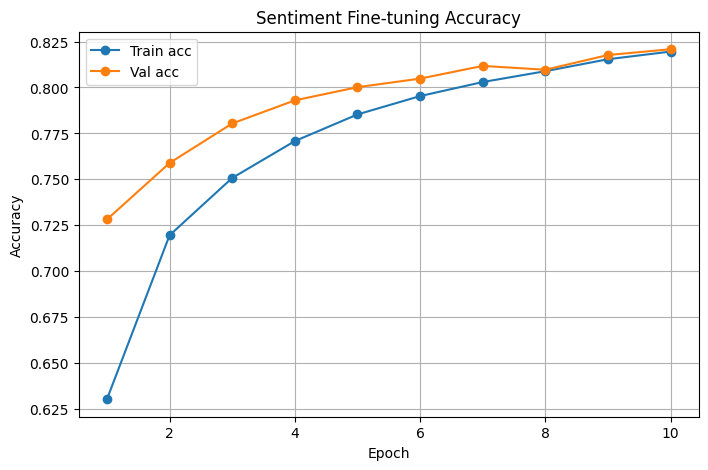

In [31]:
epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], marker="o", label="Train acc")
plt.plot(epochs, history["val_acc"], marker="o", label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Sentiment Fine-tuning Accuracy")
plt.grid(True)
plt.legend()
plt.show()